In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys,os
import math
from pathlib import Path
parent_dir = Path.cwd().parent
sys.path.append(str(parent_dir))
#sys.path.append(r"\Users\13347\Documents\Yale\Paraproducts\Quasilinearization-of-potential-and-Schrodinger-kernels-with-tensor-paraproducts-main")
from tensor_paraproducts import haar_paraproduct
import pickle
import time

In [3]:
N = 256

# Generate coordinates
hill_x = np.linspace(0.4, 0.6, N)
hill_y = np.exp(-((hill_x - 0.5) / .1) ** 2) *.6

xloc = 0.61
line_x = np.full(N, xloc)
line_y = np.linspace(0, 0.4, N)

hill_x = np.expand_dims(hill_x,axis=1)
hill_y = np.expand_dims(hill_y,axis=1)
line_x = np.expand_dims(line_x,axis=1)
line_y = np.expand_dims(line_y,axis=1)
hill = np.concatenate((hill_x,hill_y),axis=1)
line = np.concatenate((line_x,line_y),axis=1)


# Compute distance matrix
dxy = np.zeros((N,N))
for i in range(N):
    for j in range(N):
        dxy[i,j] = np.linalg.norm(hill[i] - line[j])

# Compute polynomial
deg = 5
poly = dxy**(-(deg+1))

# Compute potential kernel
Apot = np.log(poly + 1e-16)

# normalization
npoly = poly/np.max(np.abs(poly))
nApot = Apot/np.max(np.abs(Apot))
    

In [ ]:
# Initialize kernel and generate wavelet coefficients
hp = haar_paraproduct(poly,Apot)
jmax=int(math.log2(N)-1)
hp.alf = 1
hp.twave_approx(npoly,jmax,jmax)


In [5]:
# Sort coefficients by support size 
wvcoef = np.abs(np.array(hp.wvcoef))
supp = np.array(hp.supp)
sidx = np.flip(np.argsort(wvcoef))
srtwvcoef = wvcoef[sidx]
srtsupp = supp[sidx]

In [6]:
jlist = [6,8,10]
tpalist = []

for jmax in jlist:

    # Compute TPA
    hp.kernel = 'conpot'
    tpalist.append(hp.fast_tpa(jmax))   


# Figure 1: Raw Data

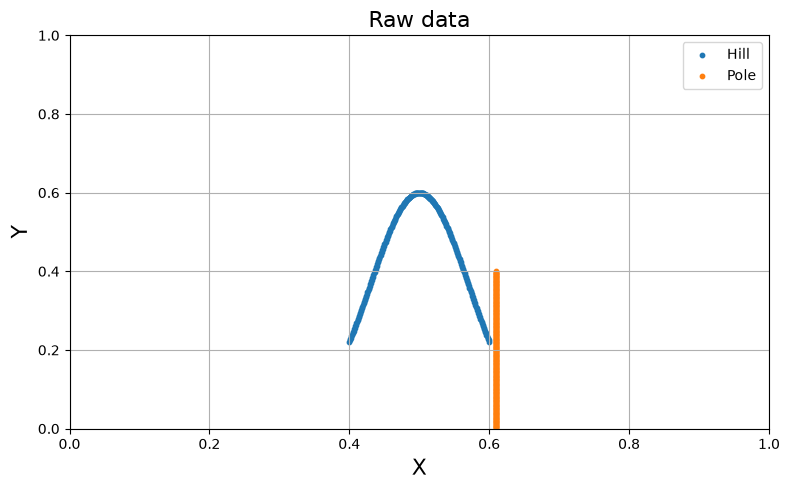

In [7]:


plt.figure(figsize=(8, 5))
plt.title("Raw data", fontsize=16)
plt.scatter(hill_x, hill_y, s=10, label='Hill')
plt.scatter(line_x, line_y, s=10, label='Pole')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel('X',fontsize=16)
plt.ylabel('Y',fontsize=16)
plt.legend()
plt.grid(True)

plt.savefig("/home/fash/Documents/Paraproducts/Quasilinearization-of-potential-and-Schrodinger-kernels-with-tensor-paraproducts-main/Figures_pot_schrod/rawdata.png")

plt.tight_layout()
plt.show()


# Figure 2: TPA Approximation and Holder regularity of D(x,y)

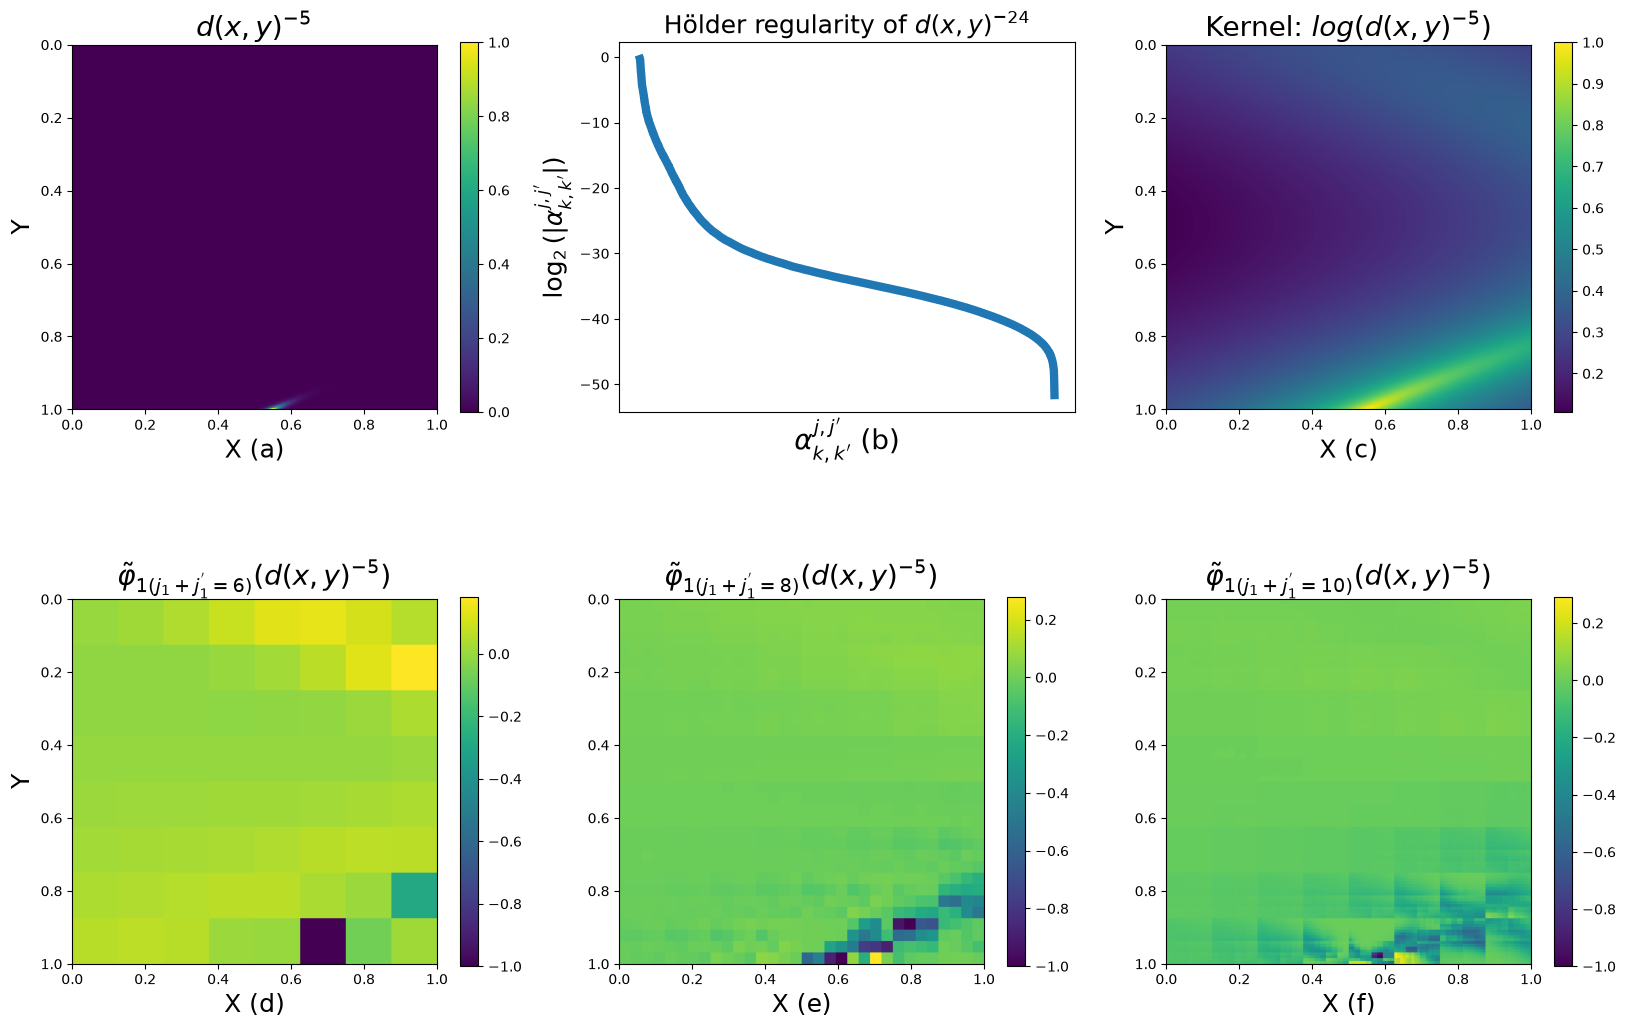

In [9]:
# Plotting
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

im1 = axes[0, 0].imshow(npoly,extent=[0, 1, 1, 0])
axes[0, 0].set_title(r"$d(x,y)^{-5}$",fontsize=20)
axes[0, 0].set_xlabel('X (a)',fontsize=18)
axes[0, 0].set_ylabel('Y',fontsize=18)
fig.colorbar(im1, ax=axes[0,0])

im2 = axes[0, 1].plot(np.log2(srtwvcoef),linewidth=6)
axes[0, 1].set_xlabel(r"$ \alpha^{j,j'}_{k,k'} $ (b)",fontsize=20)
axes[0, 1].set_ylabel(r"$log_2(|\alpha^{j,j'}_{k,k'}|)$",fontsize=18)
axes[0,1].set_ylabel(r"$\log_2(|\alpha_{k,k'}^{j,j'}|)$",fontsize=18)
axes[0,1].set_title(r"Hölder regularity of $d(x,y)^{-24}$",fontsize=18)
axes[0,1].set_xticks([])

im3 = axes[0, 2].imshow(nApot, extent=[0, 1, 1, 0])
axes[0, 2].set_title(r"Kernel: $log(d(x,y)^{-5})$",fontsize=20)
axes[0, 2].set_xlabel('X (c)',fontsize=18)
axes[0, 2].set_ylabel('Y',fontsize=18)
fig.colorbar(im3, ax=axes[0,2])

ntpazro = tpalist[0]/np.max(np.abs(tpalist[0]))
im4 = axes[1, 0].imshow(ntpazro, extent=[0, 1, 1, 0])
axes[1, 0].set_title(r"$\tilde{\varphi}_{1(j_1+j_1^{'}=6)}(d(x,y)^{-5})$",fontsize=20)
axes[1, 0].set_xlabel('X (d)',fontsize=18)
axes[1, 0].set_ylabel('Y',fontsize=18)
fig.colorbar(im4, ax=axes[1,0])

ntpaone = tpalist[1]/np.max(np.abs(tpalist[1]))
im5 = axes[1, 1].imshow(ntpaone,extent=[0, 1, 1, 0])
axes[1, 1].set_title(r"$\tilde{\varphi}_{1(j_1+j_1^{'}=8)}(d(x,y)^{-5})$",fontsize=20)
axes[1, 1].set_xlabel('X (e)',fontsize=18)
fig.colorbar(im5, ax=axes[1,1])

ntpatwo = tpalist[2]/np.max(np.abs(tpalist[2]))
im6 = axes[1, 2].imshow(ntpatwo,extent=[0, 1, 1, 0])
axes[1, 2].set_title(r"$\tilde{\varphi}_{1(j_1+j_1^{'}=10)}(d(x,y)^{-5})$",fontsize=20)
axes[1, 2].set_xlabel('X (f)',fontsize=18)
fig.colorbar(im6, ax=axes[1,2])


plt.savefig("/home/fash/Documents/Paraproducts/Quasilinearization-of-potential-and-Schrodinger-kernels-with-tensor-paraproducts-main/Figures_pot_schrod/potkern.png")
plt.subplots_adjust(hspace=0.5)
plt.show()


